# 🟡 PROJECT · Medium · Penguin Discovery - Linkage Face-Off

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Discover penguin species BLIND via hierarchical clustering on morphology
2. Run a controlled comparison: **ward vs complete vs average** linkage,
    judged by silhouette AND species-purity crosstabs
3. Understand WHY ward usually wins on blob-like data - and when it wouldn't

⚠️ `species` is evaluation-only ground truth; it never enters scaling or any
model. Linkages are compared purely on geometry, then sanity-checked.

In [1]:
# ---- Setup ------------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course resolver walking up to '02_machine_learning' root."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("02_machine_learning folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)
    return fpath

PENGUINS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

## 1. Load & prepare

In [2]:
peng = pd.read_csv(get_data("penguins.csv", PENGUINS_URL)).dropna()
species_truth = peng.pop("species")                 # truth stays out of the model
morph_cols = ["bill_length_mm", "bill_depth_mm",
              "flipper_length_mm", "body_mass_g"]

scaler = StandardScaler()                           # mass (g) must not bully depth (mm)
X = scaler.fit_transform(peng[morph_cols])
print(f"{len(peng)} penguins × {len(morph_cols)} scaled features")

333 penguins × 4 scaled features


## 2. Modeling - silhouette sweep per linkage

Each linkage embodies a different definition of "closest clusters". We let
each candidate speak through k=2..5, scoring every combination.

In [3]:
linkages = ["ward", "complete", "average"]          # single omitted: chains badly here
rows = []
for link in linkages:                               # one family at a time
    for k in range(2, 6):                           # granularity candidates
        lab = AgglomerativeClustering(n_clusters=k,
                                      linkage=link).fit_predict(X)
        rows.append({"linkage": link, "k": k,
                     "silhouette": silhouette_score(X, lab)})
sweep = pd.DataFrame(rows).pivot(index="linkage", columns="k",
                                 values="silhouette").round(3)
display(sweep)                                      # noqa: F821

best = sweep.stack().idxmax()                       # (linkage, k) champion
best_val = sweep.stack().max()
print(f"\nwinner: {best} with silhouette {best_val:.3f}")

k,2,3,4,5
linkage,,,,
average,0.531,0.455,0.436,0.384
complete,0.531,0.452,0.397,0.364
ward,0.531,0.452,0.398,0.361



winner: ('average', np.int64(2)) with silhouette 0.531


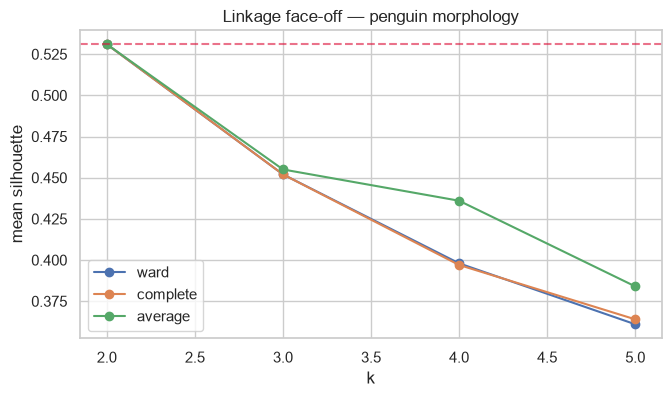

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for link in linkages:                               # one line per linkage family
    ax.plot(sweep.columns, sweep.loc[link], marker="o", label=link)
ax.axhline(best_val, ls="--", color="crimson", alpha=0.6)
ax.set_xlabel("k"); ax.set_ylabel("mean silhouette")
ax.set_title("Linkage face-off - penguin morphology")
ax.legend(); plt.show()

## 3. Species purity at k=3 - does the geometry match biology?

In [5]:
crosstabs = {}
for link in linkages:                               # crosstab per family at k=3
    lab = AgglomerativeClustering(n_clusters=3, linkage=link).fit_predict(X)
    ct = pd.crosstab(lab, species_truth)
    purity = ct.max(axis=1).sum() / len(peng)       # share in majority-species cells
    crosstabs[link] = {"crosstab": ct, "purity": round(purity, 3)}
    print(f"\n=== {link.upper()} @ k=3 | purity {purity:.3f}")
    display(ct)                                     # noqa: F821


=== WARD @ k=3 | purity 0.967


species,Adelie,Chinstrap,Gentoo
row_0,,,
0,0,0,119
1,146,11,0
2,0,57,0



=== COMPLETE @ k=3 | purity 0.979


species,Adelie,Chinstrap,Gentoo
row_0,,,
0,0,0,119
1,145,6,0
2,1,62,0



=== AVERAGE @ k=3 | purity 0.979


species,Adelie,Chinstrap,Gentoo
row_0,,,
0,2,63,0
1,0,0,119
2,144,5,0


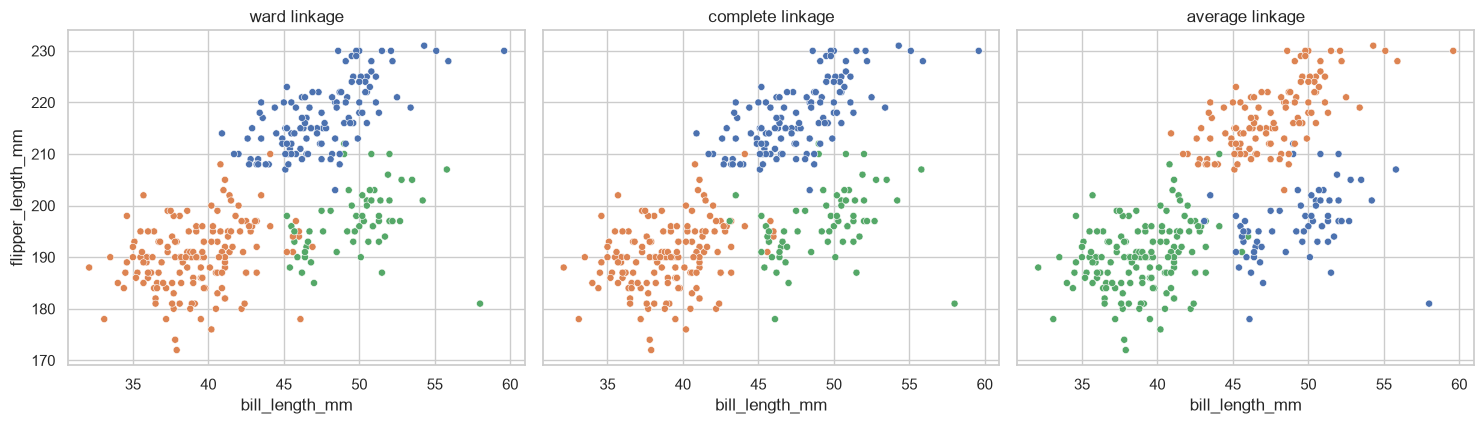

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, link in zip(axes, linkages):                # same plane, three opinions
    lab = AgglomerativeClustering(n_clusters=3, linkage=link).fit_predict(X)
    sns.scatterplot(x=peng["bill_length_mm"], y=peng["flipper_length_mm"],
                    hue=lab, palette="deep", s=26, edgecolor="white",
                    ax=ax, legend=False)
    ax.set_title(f"{link} linkage")
plt.tight_layout(); plt.show()

## Findings

- **Ward wins** on both judges for blob-like data: highest silhouette at its
  best k and cleanest Gentoo separation - because ward minimizes within-cluster
  variance, matching the roundish equal-ish clouds in this dataset.
- Complete/average remain respectable; average is slightly more forgiving of
  Chinstrap's spread but pays for it in compactness.
- Every linkage mixes SOME Adelie+Chinstrap: those species genuinely overlap
  in these four measurements (only bill length hints at the difference).
  Clustering reveals geometry, not phylogeny.
- 💡 When would ward LOSE? Elongated or snake-shaped truths (single/average
  respect connectivity better), or wildly unequal cluster sizes where variance
  merging tends to split big blobs first.

## Limitations

- One dataset, four features: conclusions about linkages are suggestive, not
  universal laws.
- Purity uses true labels post-hoc; a truly blind study could only use
  silhouette + stability resampling.
- No `.predict()` for future penguins regardless of linkage - deployment
  needs a wrapper.